## Emparejamiento de grafos con SoftAssign

## Sinkhorn

In [12]:
# ── TO IMPLEMENT ──────────────────────────────────────────────────────────────
import numpy as np

def sinkhorn(M, max_iter=30, eps=1e-3):
    """
    Alternate row/column normalization until M is doubly stochastic.

    Args:
        M        : (m×n) non-negative matrix
        max_iter : maximum iterations
        eps      : convergence threshold on ||M - M_old||₁

    Returns:
        M : doubly stochastic matrix (rows and columns sum to 1)

    Hints:
        - Normalize rows:    M = M / M.sum(axis=1, keepdims=True)
        - Normalize columns: M = M / M.sum(axis=0, keepdims=True)
        - Add 1e-10 in the denominator to avoid division by zero
        - Stop early if ||M - M_old||₁ < eps
    """
    
    for _ in range(max_iter):
        M_old = M.copy() 
        M = M/(M.sum(axis=1, keepdims=True)) # Normalizamos filas
        M = M/(M.sum(axis=0, keepdims=True)) # Normalizamos filas

        if np.abs(M-M_old).sum() < eps: # Comprobar si han cambiado mucho
            break        
        
    return M

## SoftAssign

In [14]:
def softassign(X_adj, Y_adj,
               beta0=BETA_0, beta_f=BETA_F, beta_rate=BETA_RATE,
               i0=I0, i1=I1, eps=EPS):
    """
    Graph matching by maximizing structural rectangles (Gold & Rangarajan 1996).

    Args:
        X_adj     : (m×m) adjacency matrix of G1
        Y_adj     : (n×n) adjacency matrix of G2

    Returns:
        M : (m×n) soft matching matrix

    Hints:
        - Initialize: M = ones(m,n) + 0.1*rand(m,n), then Sinkhorn
        - Outer loop: while beta < beta_f, multiply beta by beta_rate at the end
        - Inner loop (i0 iterations):
            · Q = X_adj @ M @ Y_adj
            · M = exp(beta * Q)
            · M = sinkhorn(M)
            · break if ||M - M_old||₁ < eps
    """
    
    
    n = X_adj.shape[0]
    M = np.ones((n,n))  # No es estocástica (hay que normalizarla)
    M=sinkhorn(M, max_iter=i1)
    while beta0 < beta_f:
    
        for _ in range(i0):
            M_old = M.copy()
            Q = X_adj @ M @ Y_adj
            M = np.exp(beta0*Q) 
            M = sinkhorn(M, max_iter=i1)  #Normalizamos
            
            if np.abs(M-M_old).sum() < eps:
                break
        
        beta0*=beta_rate
        
    # con bucles
    """
    for a in range(n):
        for i in range(n):
            for b in range(n):
                for j in range(n):
                    Q[a,i] += X_adj[a,b] * M[b,j] * Y_adj[i,j]
    """
    
    
    
    return M

## Clean Up

In [ ]:
def cleanup(M_soft):
    """
    Convert soft matching to binary via greedy assignment.

    Args:
        M_soft : (m×n) soft matching matrix

    Returns:
        M_binary : (m×n) binary matching matrix

    Hints:
        - Repeatedly find argmax of M_work
        - Assign that entry, then set its row and column to -inf
    """
    
    
    m,n = M_soft.shape
    M_binary = np.zeros((m,n))
    M_work = M_soft.copy()
    
    for _ in range(min(m,n)):
        f = np.argmax(np.max(M_work, axis=1))
        c = np.argmax(M_work[f])
        M_binary[f,c] = 1

        M_work[f,:] = float('-inf')
        M_work[:,c] =float('-inf')
    
    return M_binary

## Ejercicio 1

In [15]:
import numpy as np
from PIL import Image
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

# ── Hyperparameters ───────────────────────────────────────────────────────────
BETA_0    = 0.5
BETA_F    = 10.0
BETA_RATE = 1.075
I0        = 4
I1        = 30
EPS       = 0.5
OBJ_RESIZE = (256, 256)

# ── Provided utilities ────────────────────────────────────────────────────────
def load_and_preprocess_images(img_path1, img_path2, mat_path1, mat_path2):
    """
    Carga y preprocesa pares de imágenes y sus keypoints
    """
    # Definimos tamaño objeto
    obj_resize = (256,256)
    #Definimos las listas donde vamos a guardar los distintos elementos
    imgs = []
    kpts_list = []

    paths = [[img_path1, mat_path1],[img_path2, mat_path2]]

    for img_path, mat_path in paths:
        img = Image.open(img_path)
        kpts = np.array(sio.loadmat(mat_path)['pts_coord'])
        kpts[0] = kpts[0] * obj_resize[0] / img.size[0]
        kpts[1] = kpts[1] * obj_resize[1] / img.size[1]
        img = img.resize(obj_resize, resample=Image.BILINEAR)
        kpts_list.append(kpts)
        imgs.append(img)
    # Devolvemos los valores para poder usar la otra función
    return imgs[0], imgs[1], kpts_list[0], kpts_list[1]


def delaunay_triangulation(kpts):
    """
    Generate adjacency matrix based on Delaunay triangulation
    """
    # Transponemos para tener puntos como filas
    pts = kpts.T
    
    # Calculamos la triangulación de Delaunay
    tri = Delaunay(pts)
    
    # Inicializamos la matriz de adyacencia con ceros
    N = pts.shape[0]
    A = np.zeros((N, N), dtype=int)

    # Recorremos cada triángulo
    for triangle in tri.simplices:
        # triangle tiene 3 vértices: a, b, c
        a = triangle[0]
        b = triangle[1]
        c = triangle[2]

        # Conectamos a con b
        A[a, b] = 1
        A[b, a] = 1  # matriz simétrica

        # Conectamos b con c
        A[b, c] = 1
        A[c, b] = 1

        # Conectamos a comn c
        A[a, c] = 1
        A[c, a] = 1

    return A

def visualize_matching_full(img1, img2, kpts1, kpts2, adj_matrix1, adj_matrix2, matching):
    """
    Visualiza el matching completo entre dos grafos
    """
    
    # Graficar una imagen al lado de otra
    plt.figure(figsize=(15,8))
    # SI ya estan redimensionadas no haria falta (el max), simplemente se haria ancho = img1.shape
    ancho = max (img1.size[0],img2.size[0])
    alto = max (img1.size[1],img2.size[1])
    composicion = Image.new('RGB', (ancho*2, alto))
    composicion.paste(img1, (0,0))
    composicion.paste(img2, (ancho,0))
    plt.imshow(composicion)
    
    
    # Graficar las coordenadas (keypoints)
    plt.scatter(kpts1[0], kpts1[1], c='w', edgecolors='k', s=100)
    plt.scatter(kpts2[0] + ancho, kpts2[1], c='w', edgecolors='k', s=100)


    # Aristas imagen 1
    for i in range(adj_matrix1.shape[0]):
        for j in range(adj_matrix1.shape[1]):
            if adj_matrix1[i,j] == 1:
                plt.plot([kpts1[0,i], kpts1[0,j]],
                         [kpts1[1,i], kpts1[1,j]],
                         'y-', linewidth=0.5)

    # Aristas  imagen 2
    for i in range(adj_matrix2.shape[0]):
        for j in range(adj_matrix2.shape[1]):
            if adj_matrix2[i,j] == 1:
                plt.plot([kpts2[0,i] + ancho, kpts2[0,j] + ancho],
                         [kpts2[1,i], kpts2[1,j]],
                         'y-', linewidth=0.5)

    # Graficamoslas arsitas del matching
    for i in range(matching.shape[0]):
        for j in range(matching.shape[1]):
            if matching[i,j] > 0:
                color = 'g' if i==j else 'r'
                plt.plot([kpts1[0,i], kpts2[0,j] + ancho],
                         [kpts1[1,i], kpts2[1,j]],
                         color = color, linewidth=2)

# ── TO IMPLEMENT ──────────────────────────────────────────────────────────────
import numpy as np

def sinkhorn(M, max_iter=30, eps=1e-3):
    """
    Alternate row/column normalization until M is doubly stochastic.

    Args:
        M        : (m×n) non-negative matrix
        max_iter : maximum iterations
        eps      : convergence threshold on ||M - M_old||₁

    Returns:
        M : doubly stochastic matrix (rows and columns sum to 1)

    Hints:
        - Normalize rows:    M = M / M.sum(axis=1, keepdims=True)
        - Normalize columns: M = M / M.sum(axis=0, keepdims=True)
        - Add 1e-10 in the denominator to avoid division by zero
        - Stop early if ||M - M_old||₁ < eps
    """
    
    for _ in range(max_iter):
        M_old = M.copy() 
        M = M/(M.sum(axis=1, keepdims=True)) # Normalizamos filas
        M = M/(M.sum(axis=0, keepdims=True)) # Normalizamos filas

        if np.abs(M-M_old).sum() < eps: # Comprobar si han cambiado mucho
            break        
        
    return M


def softassign(X_adj, Y_adj,
               beta0=BETA_0, beta_f=BETA_F, beta_rate=BETA_RATE,
               i0=I0, i1=I1, eps=EPS):
    """
    Graph matching by maximizing structural rectangles (Gold & Rangarajan 1996).

    Args:
        X_adj     : (m×m) adjacency matrix of G1
        Y_adj     : (n×n) adjacency matrix of G2

    Returns:
        M : (m×n) soft matching matrix

    Hints:
        - Initialize: M = ones(m,n) + 0.1*rand(m,n), then Sinkhorn
        - Outer loop: while beta < beta_f, multiply beta by beta_rate at the end
        - Inner loop (i0 iterations):
            · Q = X_adj @ M @ Y_adj
            · M = exp(beta * Q)
            · M = sinkhorn(M)
            · break if ||M - M_old||₁ < eps
    """
    
    
    n = X_adj.shape[0]
    M = np.ones((n,n))  # No es estocástica (hay que normalizarla)
    M=sinkhorn(M, max_iter=i1)
    while beta0 < beta_f:
    
        for _ in range(i0):
            M_old = M.copy()
            Q = X_adj @ M @ Y_adj
            M = np.exp(beta0*Q) 
            M = sinkhorn(M, max_iter=i1)  #Normalizamos
            
            if np.abs(M-M_old).sum() < eps:
                break
        
        beta0*=beta_rate
        

    """
    Con bucles
    ----------

    for a in range(n):
        for i in range(n):
            for b in range(n):
                for j in range(n):
                    Q[a,i] += X_adj[a,b] * M[b,j] * Y_adj[i,j]
    """
    return M


def cleanup(M_soft):
    """
    Convert soft matching to binary via greedy assignment.

    Args:
        M_soft : (m×n) soft matching matrix

    Returns:
        M_binary : (m×n) binary matching matrix

    Hints:
        - Repeatedly find argmax of M_work
        - Assign that entry, then set its row and column to -inf
    """
    
    
    m,n = M_soft.shape
    M_binary = np.zeros((m,n))
    M_work = M_soft.copy()
    
    for _ in range(min(m,n)):
        f = np.argmax(np.max(M_work, axis=1))
        c = np.argmax(M_work[f])
        M_binary[f,c] = 1

        M_work[f,:] = float('-inf')
        M_work[:,c] =float('-inf')
    
    return M_binary

### Ej 2

Accuracy: 2/10 = 20.0%


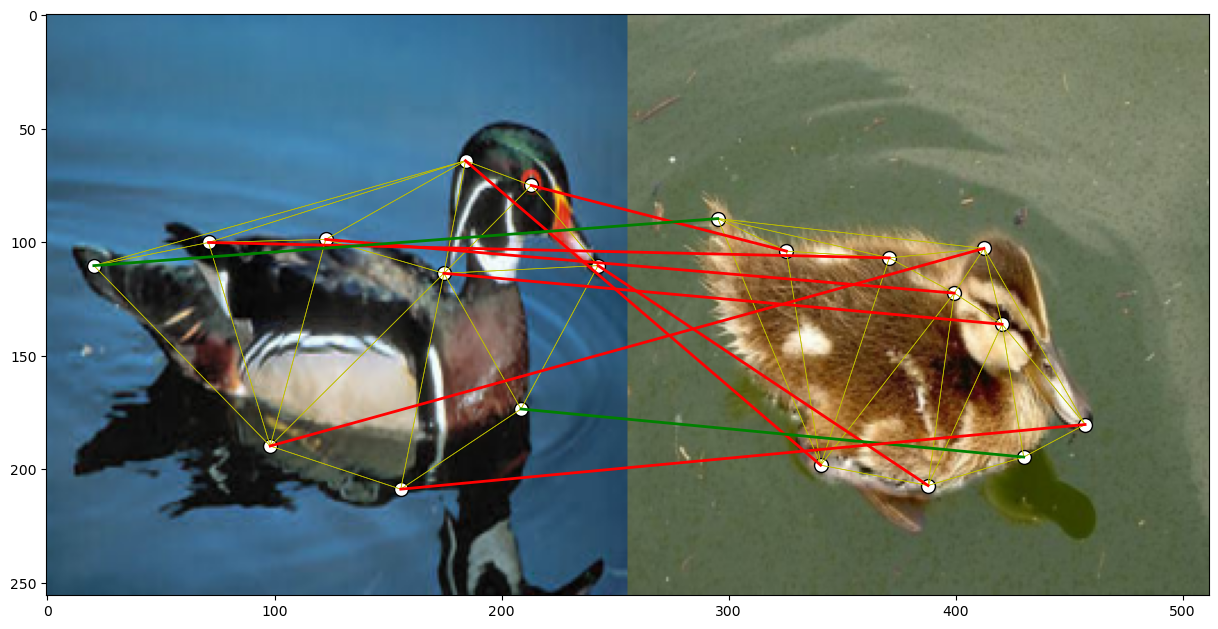

In [18]:
img1, img2, kpts1, kpts2 = load_and_preprocess_images(
    './data/WillowObject/WILLOW-ObjectClass/Duck/060_0081.png',
    './data/WillowObject/WILLOW-ObjectClass/Duck/060_0066.png',
    './data/WillowObject/WILLOW-ObjectClass/Duck/060_0081.mat',
    './data/WillowObject/WILLOW-ObjectClass/Duck/060_0066.mat'
)

A1 = delaunay_triangulation(kpts1)
A2 = delaunay_triangulation(kpts2)

M_soft   = softassign(A1, A2)
matching = cleanup(M_soft)

correct = int(np.trace(matching))
total   = int(matching.sum())
print(f"Accuracy: {correct}/{total} = {correct/total*100:.1f}%")

fig = visualize_matching_full(img1, img2, kpts1, kpts2, A1, A2, matching)
plt.savefig('./images/duck_softassign.png', dpi=150, bbox_inches='tight')

plt.show()

## Ejercicio 3 - Ajuste de Hiperparámetros

Vamos a seleccionar un par de imágenes para cada categoría:

### Car

### Duck

### Motorbike

### Face

### Winebottle